# Notebook 4: Results Visualization
**Purpose:** Generate final visual artifacts for the project report, including cross-validated parity plots, pareto front analysis for optimal EUV candidates, and family-wise feature importance charts.

✅ Loaded 7786 compounds


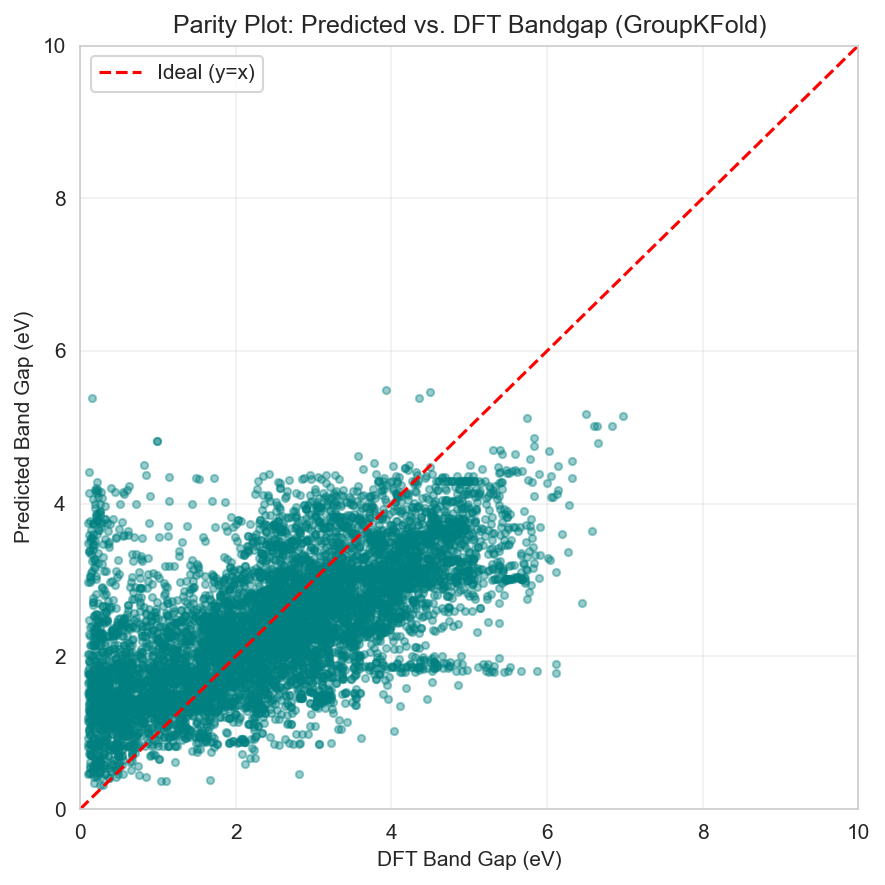

✅ Figure 4 saved (Parity Plot)


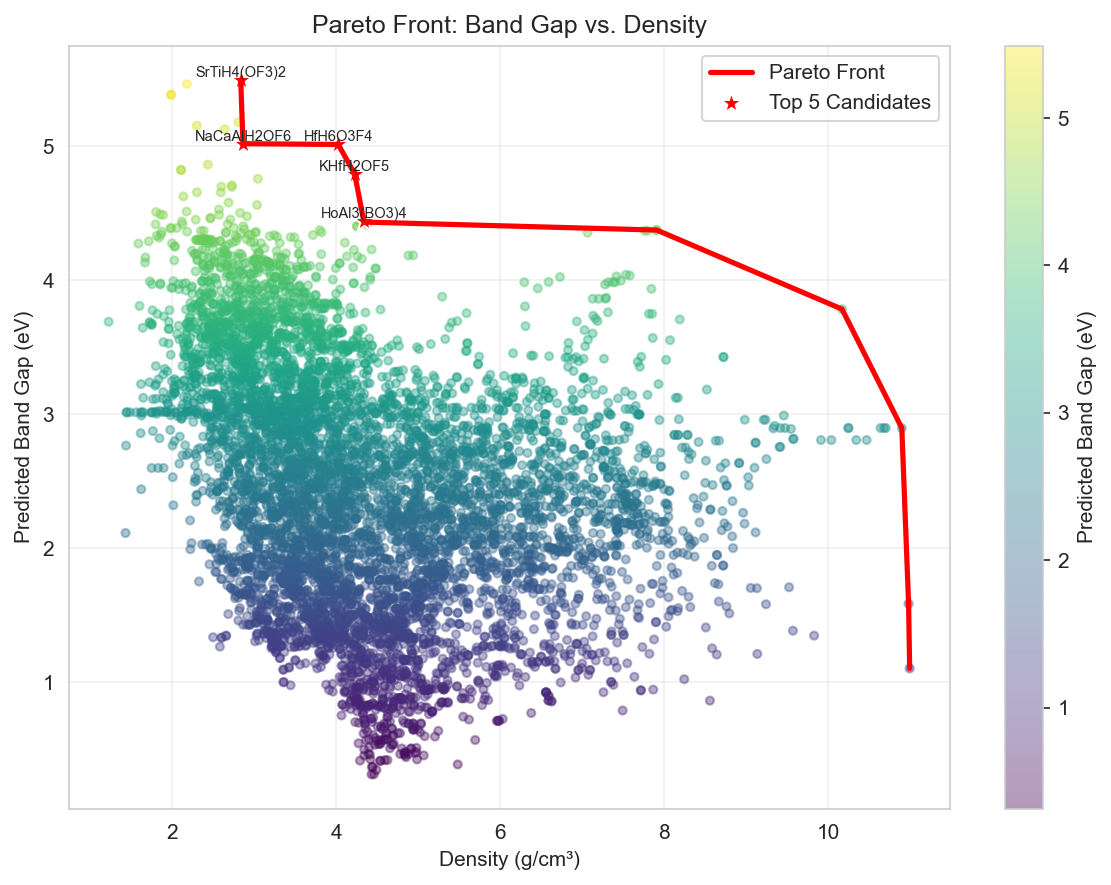

✅ Figure 5 saved (Pareto Front)

🏆 Top 5 EUV Candidates:
           formula metal_group  density  bandgap_pred
1849  SrTiH4(OF3)2          Ti   2.8381        5.4921
4336   NaCaAlH2OF6          Al   2.8659        5.0183
937       HfH6O3F4          Hf   4.0267        5.0127
1003      KHfH2OF5          Hf   4.2269        4.7924
4762   HoAl3(BO3)4          Al   4.3386        4.4379


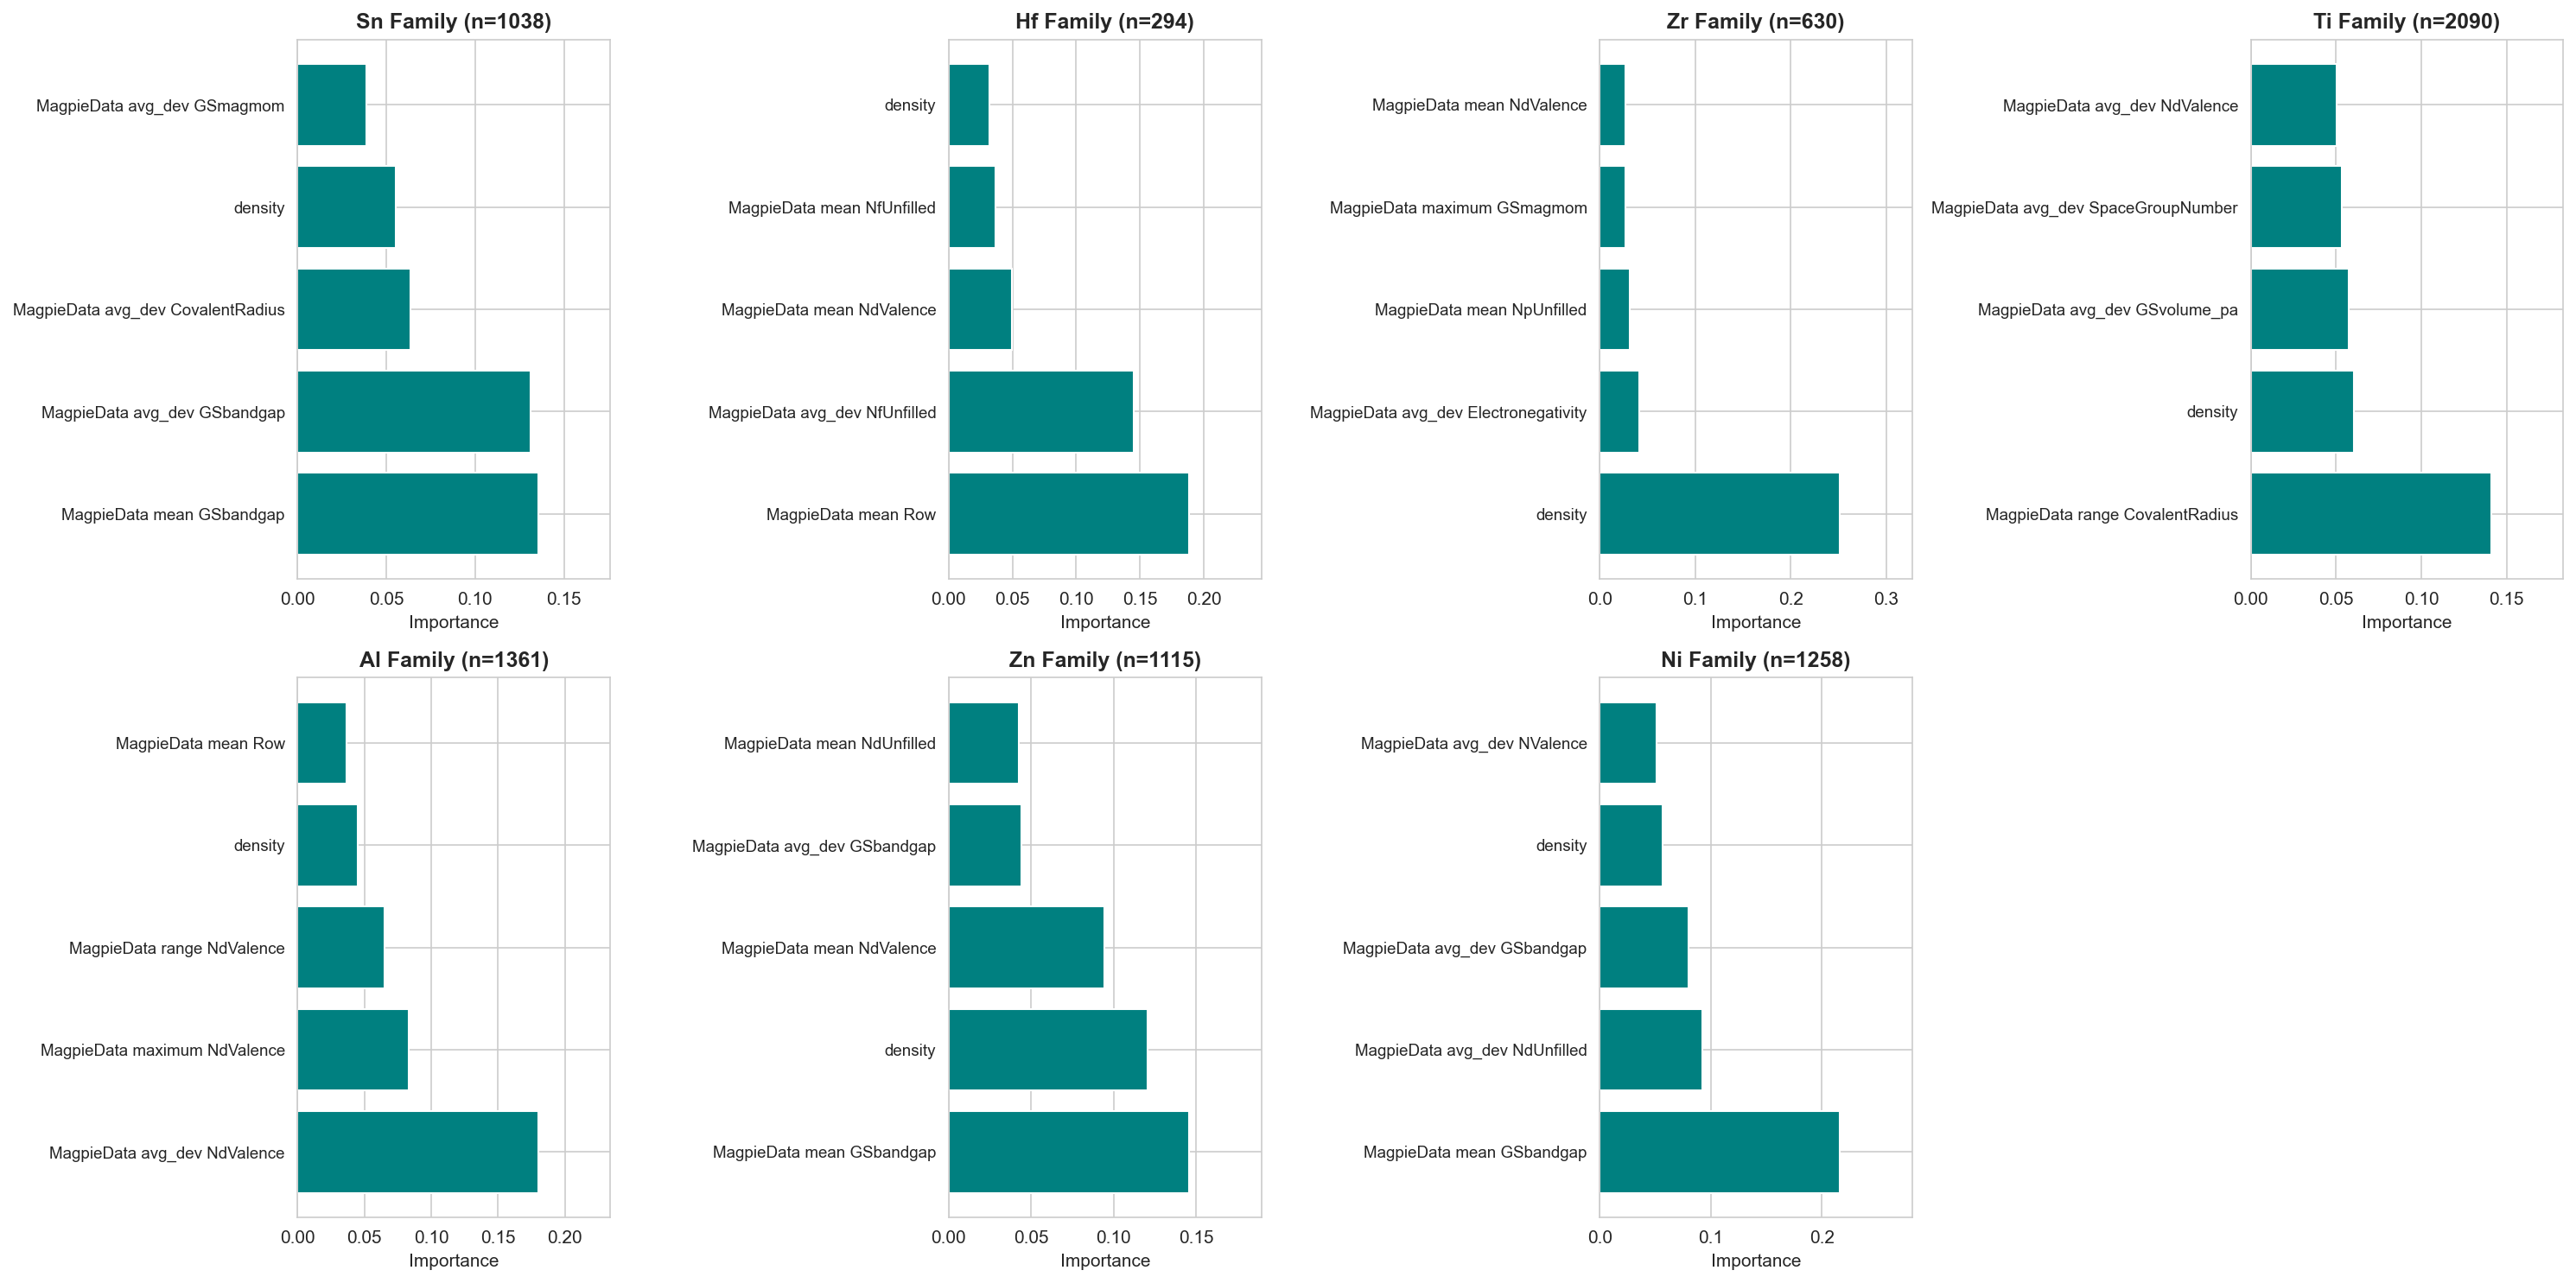

✅ Figure 6 saved (Feature Importance)

✅ Notebook 4 completed successfully!


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline

%matplotlib inline
plt.rcParams['figure.dpi'] = 150
sns.set_style('whitegrid')

# Load data
df = pd.read_csv('data/featurized_data.csv')
print(f"✅ Loaded {len(df)} compounds")

# Reconstruct metal_group
metals = ["Sn", "Hf", "Zr", "Ti", "Al", "Zn", "Ni"]
def assign_group(formula):
    for m in metals:
        if m in formula:
            return m
    return "Other"

if 'metal_group' not in df.columns:
    df['metal_group'] = df['formula'].apply(assign_group)

magpie_cols = [col for col in df.columns if col.startswith('MagpieData')]
feature_cols = magpie_cols + ['density']

X = df[feature_cols].values
y = df['band_gap'].values
groups = df['metal_group'].values # GroupKFold

os.makedirs('figures', exist_ok=True)

# ============================================================
# Figure 4: Parity Plot (no Data Leakage)
# ============================================================
# cross check with pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])
gkf = GroupKFold(n_splits=5)

y_pred_cv = cross_val_predict(pipeline, X, y, cv=gkf, groups=groups)

plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred_cv, alpha=0.4, s=12, color='teal') # y_pred_cv 
plt.plot([0, 10], [0, 10], 'r--', lw=1.5, label='Ideal (y=x)')
plt.xlabel('DFT Band Gap (eV)')
plt.ylabel('Predicted Band Gap (eV)')
plt.title('Parity Plot: Predicted vs. DFT Bandgap (GroupKFold)')
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/figure4_parity_plot.png', dpi=200)
plt.show()
print("✅ Figure 4 saved (Parity Plot)")

# ============================================================
# Figure 5: Pareto Front
# ============================================================
df['bandgap_pred'] = y_pred_cv
sorted_df = df.sort_values('density', ascending=False)
pareto_points = []
max_bandgap = -np.inf

for _, row in sorted_df.iterrows():
    if row['bandgap_pred'] > max_bandgap:
        pareto_points.append(row)
        max_bandgap = row['bandgap_pred']

pareto_front = pd.DataFrame(pareto_points).sort_values('density', ascending=True)
top5 = pareto_front.head(5)

plt.figure(figsize=(8, 6))
sc = plt.scatter(df['density'], df['bandgap_pred'], c=df['bandgap_pred'], 
                 cmap='viridis', alpha=0.4, s=15)
plt.colorbar(sc, label='Predicted Band Gap (eV)')
plt.plot(pareto_front['density'], pareto_front['bandgap_pred'], 
         'r-', lw=2.5, label='Pareto Front')
plt.scatter(top5['density'], top5['bandgap_pred'], 
            color='red', s=120, marker='*', edgecolors='white', 
            label='Top 5 Candidates')

for _, row in top5.iterrows():
    plt.annotate(row['formula'], (row['density'], row['bandgap_pred']), 
                 fontsize=7, ha='center', va='bottom')
plt.xlabel('Density (g/cm³)')
plt.ylabel('Predicted Band Gap (eV)')
plt.title('Pareto Front: Band Gap vs. Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/figure5_pareto_front.png', dpi=200)
plt.show()
print("✅ Figure 5 saved (Pareto Front)")

print("\n🏆 Top 5 EUV Candidates:")
print(top5[['formula', 'metal_group', 'density', 'bandgap_pred']].round(4))

# ============================================================
# Figure 6: Feature Importance by Family
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

metals_to_plot = df['metal_group'].unique()[:7]

for idx, metal in enumerate(metals_to_plot):
    df_fam = df[df['metal_group'] == metal]
    if len(df_fam) < 20:
        axes[idx].text(0.5, 0.5, f"{metal}\n(no data)", ha='center', va='center')
        continue

    X_fam = df_fam[feature_cols].values
    y_fam = df_fam['band_gap'].values
    scaler = StandardScaler()
    rf_fam = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_fam.fit(scaler.fit_transform(X_fam), y_fam)

    imp = pd.Series(rf_fam.feature_importances_, index=feature_cols)
    top5_imp = imp.nlargest(5)
    
    # graph draw
    axes[idx].barh(top5_imp.index, top5_imp.values, color='teal')
    axes[idx].set_title(f'{metal} Family (n={len(df_fam)})', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Importance', fontsize=10)
    axes[idx].set_xlim(0, max(top5_imp.values) * 1.3)
    axes[idx].tick_params(axis='y', labelsize=9)

axes[7].axis('off')

# graph size optimize
plt.tight_layout()
plt.savefig('figures/figure6_feature_importance_wide.png', dpi=200)
plt.show()
print("✅ Figure 6 saved (Feature Importance)")

print("\n✅ Notebook 4 completed successfully!")